In [1]:
import neo
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.fft import fft, fftfreq
from scipy import signal

In [18]:
def generate_sine_wave(duration=1.0, sampling_rate=1000, frequency=1.0, amplitude=1.0, phase_shift=0.0):
    """
    任意のsin波を生成する関数
    
    Parameters:
    ----------
    duration : float
        信号の長さ（秒）
    sampling_rate : int
        サンプリングレート（Hz）
    frequency : float
        周波数（Hz）
    amplitude : float
        振幅
    phase_shift : float
        位相のずれ（ラジアン）
    
    Returns:
    -------
    t : ndarray
        時間軸の配列
    signal : ndarray
        生成されたsin波
    """
    # 時間軸の作成
    t = np.arange(0, duration, 1.0/sampling_rate)
    
    # sin波の生成
    signal = amplitude * np.sin(2 * np.pi * frequency * t + phase_shift)
    
    return signal

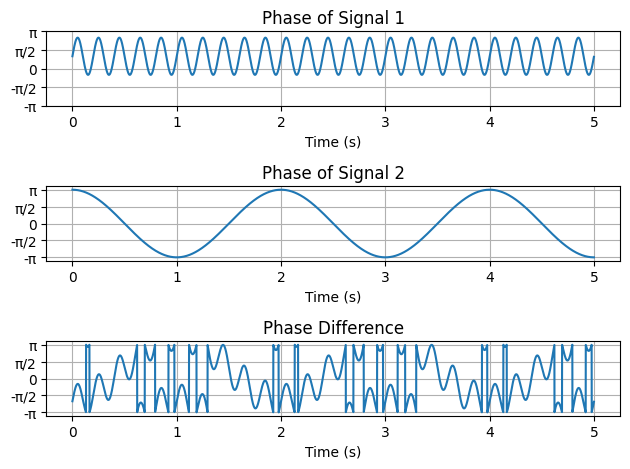

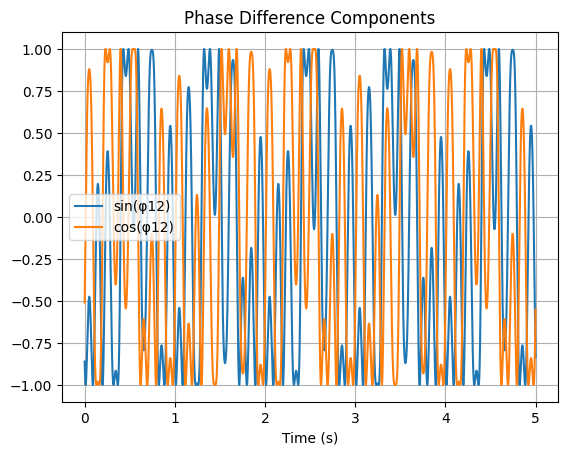

0.14405105903151502


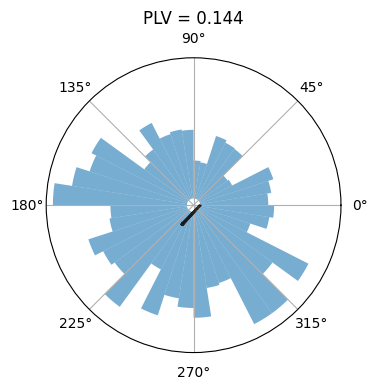

In [109]:
# phase locking analysis, ヒルベルト変換の勉強
t = np.arange(0, 5, 0.001)
phi_1 = generate_sine_wave(duration=5.0, sampling_rate=1000, frequency=5.0, amplitude=math.pi/2, phase_shift=0.0)
phi_2 = generate_sine_wave(duration=5.0, sampling_rate=1000, frequency=0.5, amplitude=math.pi, phase_shift=np.pi/2)
phi_1 += np.pi * 0.33
phi_12 = phi_1 - phi_2
# -πからπの範囲に正規化
phi_12 = np.mod(phi_12 + np.pi, 2 * np.pi) - np.pi

plt.figure()
plt.subplot(3, 1, 1)
plt.plot(t, phi_1)
plt.title('Phase of Signal 1')
plt.xlabel('Time (s)')
plt.yticks(np.arange(-np.pi, np.pi + 0.1, np.pi/2), ['-π', '-π/2', '0', 'π/2', 'π'])
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t, phi_2)
plt.title('Phase of Signal 2')
plt.xlabel('Time (s)')
plt.yticks(np.arange(-np.pi, np.pi + 0.1, np.pi/2), ['-π', '-π/2', '0', 'π/2', 'π'])
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t, phi_12)
plt.title('Phase Difference')
plt.xlabel('Time (s)')
plt.yticks(np.arange(-np.pi, np.pi + 0.1, np.pi/2), ['-π', '-π/2', '0', 'π/2', 'π'])
plt.grid()
plt.tight_layout()
plt.show()

sin_phi_12 = np.sin(phi_12)
cos_phi_12 = np.cos(phi_12)

plt.figure()
plt.plot(t, sin_phi_12, label='sin(φ12)')
plt.plot(t, cos_phi_12, label='cos(φ12)')
plt.title('Phase Difference Components')
plt.xlabel('Time (s)')
plt.legend()
plt.grid()
plt.show()

# 複素数表現に変換
complex_phase_diff = np.exp(1j * phi_12)
# 平均化してPLVを計算
plv = np.abs(np.mean(complex_phase_diff))
# 同値
# plv = np.sqrt(np.mean(sin_phi_12) ** 2 + np.mean(cos_phi_12) ** 2)

print(plv)

# 特定チャンネルペアの位相差分布（円形ヒストグラム）

# 平均ベクトルを計算
mean_vector = np.mean(np.exp(1j * phi_12))
mean_angle = np.angle(mean_vector)
mean_length = np.abs(mean_vector)

# 円形ヒストグラム表示
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='polar')

# ヒストグラム
bins = np.linspace(-np.pi, np.pi, 41)  # 40分割（9度ごと）
counts, edges = np.histogram(phi_12, bins=bins)
width = 2 * np.pi / 40

# 部分円の描画（部分円の大きさが頻度を表す）
x = edges[:-1] + (np.diff(bins).mean() / 2)
# x = edges[:-1]
y = counts
bars = ax.bar(x, y, width=width, alpha=0.6)

# 平均ベクトル（PLV）の描画
ax.arrow(0, 0, mean_angle, mean_length * max(counts) * 0.8, alpha=0.8, 
         width=0.05, edgecolor='black', facecolor='red', lw=2, zorder=5)

# ラベルとタイトル
ax.set_rticks([])  # 半径目盛りを非表示
ax.set_title(f"PLV = {plv:.3f}")

plt.tight_layout()
plt.show()

0.22279349905641713
